In [27]:
import earthkit.data
import earthkit.plots
import earthkit.regrid
from earthkit.transforms import aggregate as ek_aggregate

from earthkit.data.testing import earthkit_remote_test_data_file
import earthkit.plots.quickmap as qmap
import matplotlib.pyplot as plt
from polytope.api import Client

In [28]:
# Set True if you want to make a live request for the data, or false if you want to use the cached grib file
LIVE_REQUEST = True

In [29]:
request = {
"activity": "ScenarioMIP",

        "class": "d1",

        "dataset": "climate-dt",

        "date": "20200101/to/20200101",

        "experiment": "SSP3-7.0",

        "expver": "0001",

        "generation": 1,

        "levtype": "sfc",

        "model": "IFS-NEMO",

        "param": "134/165/166",

        "realization": 1,

        "resolution": "high",

        "stream": "clte",

        "time": "0000",

        "type": "fc"
        
}

In [30]:
data1 = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)


DEBUG:polytope.api.Client.R6YVK6:Gathered Polytope client configuration:
{'address': 'polytope.lumi.apps.dte.destination-earth.eu',
 'insecure': False,
 'key_path': PosixPath('/Users/maes/.polytopeapirc'),
 'log_file': None,
 'log_level': 'DEBUG',
 'password': None,
 'port': None,
 'quiet': False,
 'skip_tls': False,
 'user_email': None,
 'user_key': None,
 'username': 'maes',
 'verbose': False}
DEBUG:polytope.api.Client.R6YVK6:Creating Polytope client...
2025-09-05 13:05:13 - INFO - Key read from /Users/maes/.polytopeapirc
INFO:polytope.api.Client.R6YVK6:Key read from /Users/maes/.polytopeapirc
2025-09-05 13:05:13 - INFO - Sending request...
{'request': 'activity: ScenarioMIP\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20200101/to/20200101\n'
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            'generation: 1\n'
            'levtype: sfc\n'
            'model: IFS-NEMO\n'
            'param: 134/165/166\n'
            

In [32]:
data1.ls()


,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,sp,surface,0,20200101,0,0,fc,None,healpix
1,ecmf,10u,heightAboveGround,10,20200101,0,0,fc,None,healpix
2,ecmf,10v,heightAboveGround,10,20200101,0,0,fc,None,healpix


In [4]:
data3 = earthkit.data.from_source("polytope", "destination-earth", request3, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)


DEBUG:polytope.api.Client.2V7SCN:Gathered Polytope client configuration:
{'address': 'polytope.lumi.apps.dte.destination-earth.eu',
 'insecure': False,
 'key_path': PosixPath('/Users/maes/.polytopeapirc'),
 'log_file': None,
 'log_level': 'DEBUG',
 'password': None,
 'port': None,
 'quiet': False,
 'skip_tls': False,
 'user_email': None,
 'user_key': None,
 'username': 'maes',
 'verbose': False}
DEBUG:polytope.api.Client.2V7SCN:Creating Polytope client...
2025-08-25 17:11:10 - INFO - Key read from /Users/maes/.polytopeapirc
INFO:polytope.api.Client.2V7SCN:Key read from /Users/maes/.polytopeapirc
2025-08-25 17:11:10 - INFO - Sending request...
{'request': 'activity: ScenarioMIP\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20200102'\n"
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            "generation: '1'\n"
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            "param: '134'\n"
            "realization:

HTTPResponseError: Polytope error
Situation: trying to download data
Description: HTTP CLIENT ERROR (400)
URL: https://polytope.lumi.apps.dte.destination-earth.eu:443/api/v1/requests/e3688091-be35-4897-b3b4-2fb0988d3311
HTTP method: GET
Request header/body contents:
{'headers': {'Authorization': 'EmailKey **********35fd'}, 'json': None}
Expected responses: 200, 202
Received response: CLIENT ERROR (400)
Details:
Request failed with error:
Matched datasource mars-climate-dt

No data retrieved

In [ ]:
data_file = "data/climate-dt-earthkit-aoi-example.grib"
if LIVE_REQUEST:
    data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)
    data.to_target("file", data_file)
else:
    data = earthkit.data.from_source("file", data_file)

In [6]:
data.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,sp,surface,0,20200102,100,0,fc,None,healpix
1,ecmf,10u,heightAboveGround,10,20200102,100,0,fc,None,healpix
2,ecmf,10v,heightAboveGround,10,20200102,100,0,fc,None,healpix
3,ecmf,2t,heightAboveGround,2,20200102,100,0,fc,None,healpix


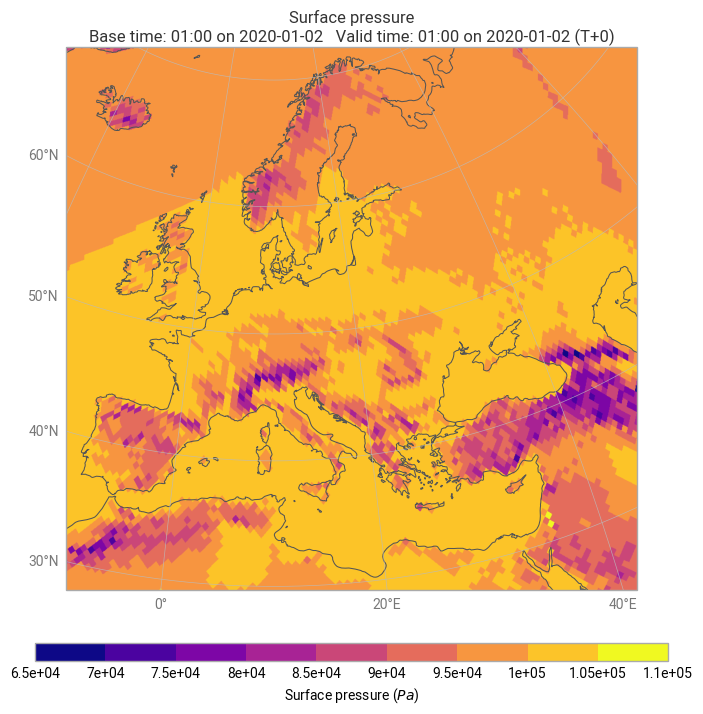

In [7]:
chart = earthkit.plots.Map(domain="Europe")
chart.grid_cells(data[0])
chart.legend()
chart.gridlines()
chart.title()
chart.coastlines()
chart.show()


In [8]:
# Regrid t=from healpix for conversion to xarray
data_latlon = earthkit.regrid.interpolate(data, out_grid={"grid": [0.1,0.1]}, method="linear")